In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()

satellites = resolved[
    (resolved["IsSatellite"] == True) &
    resolved[["x", "y", "z"]].notna().all(axis=1)
].copy()

nearest_distances = []

for _, central in centrals.iterrows():

    sats = satellites[
        satellites["GroupID"] == central["GroupID"]
    ]

    if len(sats) == 0:
        nearest_distances.append(np.nan)
        continue

    box_size = 205000.0  # TNG300-1 box size in ckpc/h

    dx = np.abs(sats["x"].to_numpy() - central["x"])
    dy = np.abs(sats["y"].to_numpy() - central["y"])
    dz = np.abs(sats["z"].to_numpy() - central["z"])

    dx = np.minimum(dx, box_size - dx)
    dy = np.minimum(dy, box_size - dy)
    dz = np.minimum(dz, box_size - dz)

    distances = np.sqrt(dx**2 + dy**2 + dz**2)


    nearest_distances.append(np.min(distances))

centrals["NearestSatelliteDistance"] = nearest_distances
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Centrals: {len(centrals):,}")
print(f"DMDGS (total): {len(dmdgs):,}")
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")
print(f"DMDGS Fraction: {(len(dmdgs_non_extreme) / len(centrals)):,}")


Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)
print(f"Total Catalog Objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")

resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)

mass_selected = resolved[
    (resolved["M_star_Msun"] > 1e9) &
    (resolved["M_star_Msun"] < 1e10)
].copy()
satellites = mass_selected[
    mass_selected["IsSatellite"] == True
].copy()
satellites["Host_M200c_Msun"] = (
    satellites["Host_M200c"] * 1e10 / 0.6774
)
group_selected = satellites[
    satellites["Host_M200c_Msun"] > 1e13
].copy()
dmdgs = group_selected[
    group_selected["f_DM"] < 0.5
].copy()
dmdgs_non_extreme_satellites = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme_satellites):,}")

Total Catalog Objects: 13,922,457
Resolved galaxies: 154,638
DMDGS (non-tidal stripping): 400


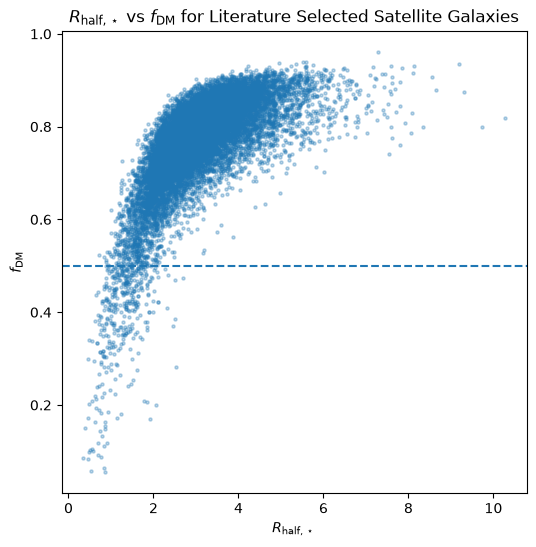

0.6884900797728248


In [4]:
group_selected_non_extreme = group_selected[
   group_selected["f_DM" ]> 0.05
].copy()
plt.figure(figsize=(6, 6))
plt.scatter(group_selected_non_extreme["R_half_star"], group_selected_non_extreme["f_DM"], s=5, alpha=0.3)
plt.xlabel("$R_{\\text{half}, \\star}$")
plt.ylabel("$f_{\\text{DM}}$")
plt.axhline(0.5, linestyle='--')
plt.title("$R_{\\text{half}, \\star}$ vs $f_{\\text{DM}}$ for Literature Selected Satellite Galaxies")
plt.show()
matrix = np.corrcoef(group_selected_non_extreme["R_half_star"], group_selected_non_extreme["f_DM"])
corr_coefficient = matrix[0, 1]
print (corr_coefficient)

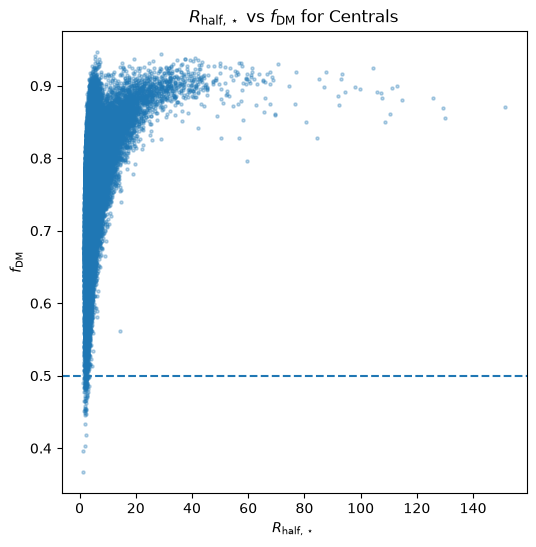

0.3956761672116938


In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(centrals["R_half_star"], centrals["f_DM"], s=5, alpha=0.3)
plt.xlabel("$R_{\\text{half}, \\star}$")
plt.ylabel("$f_{\\text{DM}}$")
plt.axhline(0.5, linestyle='--')
plt.title("$R_{\\text{half}, \\star}$ vs $f_{\\text{DM}}$ for Centrals")
plt.show()
matrix = np.corrcoef(centrals["R_half_star"], centrals["f_DM"])
corr_coefficient = matrix[0, 1]
print (corr_coefficient)

In [6]:
from scipy.stats import spearmanr
group_selected_data = group_selected[
    ["f_DM", "R_half_star"]
].dropna()
rho, p_value = spearmanr(
    group_selected_data["f_DM"],
    group_selected_data["R_half_star"]
)
print("Spearman rho:", rho)
print("p-value:", p_value)
print("N:", len(group_selected_data))

Spearman rho: 0.7457211958838021
p-value: 0.0
N: 15595


In [7]:
from scipy.stats import spearmanr
centrals_data = centrals[
    ["f_DM", "R_half_star"]
].dropna()
rho, p_value = spearmanr(
    centrals_data["f_DM"],
    centrals_data["R_half_star"]
)
print("Spearman rho:", rho)
print("p-value:", p_value)
print("N:", len(centrals_data))

Spearman rho: 0.5037603334801074
p-value: 0.0
N: 93039
